# Churn Rate con LightGBM

In [1]:
import os
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
print(f"LightGBM {lgb.__version__}")

LightGBM 4.6.0


## 1. Carga y preparación de datos

In [2]:
DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

target_col = "Churn"
y = (df[target_col] == "Yes").astype(int).to_numpy()
X = df.drop(columns=[target_col])

num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = [column for column in X.columns if column not in num_features]

print(df.shape)
df[target_col].value_counts()

(7043, 20)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 2. Mismos splits y preprocesamiento que la red neuronal

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_features),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("Train / validation / test:", X_train_prep.shape, X_val_prep.shape, X_test_prep.shape)

Train / validation / test: (5088, 46) (898, 46) (1057, 46)


## 3. Modelo LightGBM

In [4]:
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

model.fit(
    X_train_prep,
    y_train,
    eval_set=[(X_val_prep, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print("Mejor iteración:", model.best_iteration_)

Mejor iteración: 190


## 4. Evaluación y selección del umbral

In [5]:
def predict_probabilities(features):
    return model.predict_proba(features, num_iteration=model.best_iteration_)[:, 1]

def evaluate_split(name, features, labels, threshold):
    probabilities = predict_probabilities(features)
    predictions = (probabilities >= threshold).astype(int)
    score = f1_score(labels, predictions)
    print(f"\n{name} F1 @ {threshold:.4f}: {score:.4f}")
    print(classification_report(labels, predictions, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(labels, predictions))
    return score

f1_test_default = evaluate_split("Test", X_test_prep, y_test, threshold=0.5)

y_val_probability = predict_probabilities(X_val_prep)
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probability)
f1_values = 2 * precision * recall / (precision + recall + np.finfo(float).eps)
best_index = np.argmax(f1_values[:-1])
decision_threshold = float(thresholds[best_index])

print(f"\nUmbral seleccionado en validation: {decision_threshold:.4f}")
f1_val_tuned = evaluate_split("Validation (tuned threshold)", X_val_prep, y_val, decision_threshold)
f1_test_tuned = evaluate_split("Test (tuned threshold)", X_test_prep, y_test, decision_threshold)


Test F1 @ 0.5000: 0.5913
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       777
           1       0.67      0.53      0.59       280

    accuracy                           0.81      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.80      0.81      0.80      1057

Confusion matrix:
 [[702  75]
 [131 149]]

Umbral seleccionado en validation: 0.2849

Validation (tuned threshold) F1 @ 0.2849: 0.6379
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       660
           1       0.54      0.78      0.64       238

    accuracy                           0.77       898
   macro avg       0.72      0.77      0.73       898
weighted avg       0.81      0.77      0.78       898

Confusion matrix:
 [[503 157]
 [ 53 185]]

Test (tuned threshold) F1 @ 0.2849: 0.6399
              precision    recall  f1-score   support

           0       0.91      0.75      0.82 

/home/gibran/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/gibran/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/gibran/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/gibran/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5. Comparación de F1

,F1 test @ 0.5,F1 test @ umbral ajustado
modelo,,
Red neuronal,0.5786,0.6209
LightGBM,0.5913,0.6399


Diferencia LightGBM - NN (umbral ajustado): +0.0190


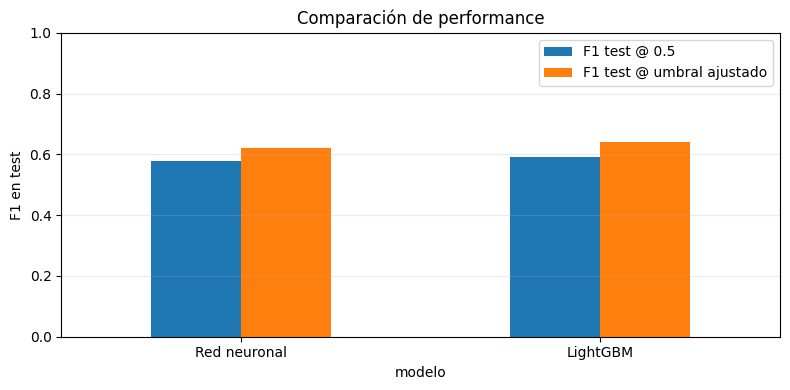

In [6]:
nn_f1_default = 0.5786
nn_f1_tuned = 0.6209

comparison = pd.DataFrame({
    "modelo": ["Red neuronal", "LightGBM"],
    "F1 test @ 0.5": [nn_f1_default, f1_test_default],
    "F1 test @ umbral ajustado": [nn_f1_tuned, f1_test_tuned],
}).set_index("modelo")

display(comparison.round(4))
print(f"Diferencia LightGBM - NN (umbral ajustado): {f1_test_tuned - nn_f1_tuned:+.4f}")

comparison.plot(kind="bar", ylim=(0, 1), rot=0, figsize=(8, 4))
plt.ylabel("F1 en test")
plt.title("Comparación de performance")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Importancia de variables

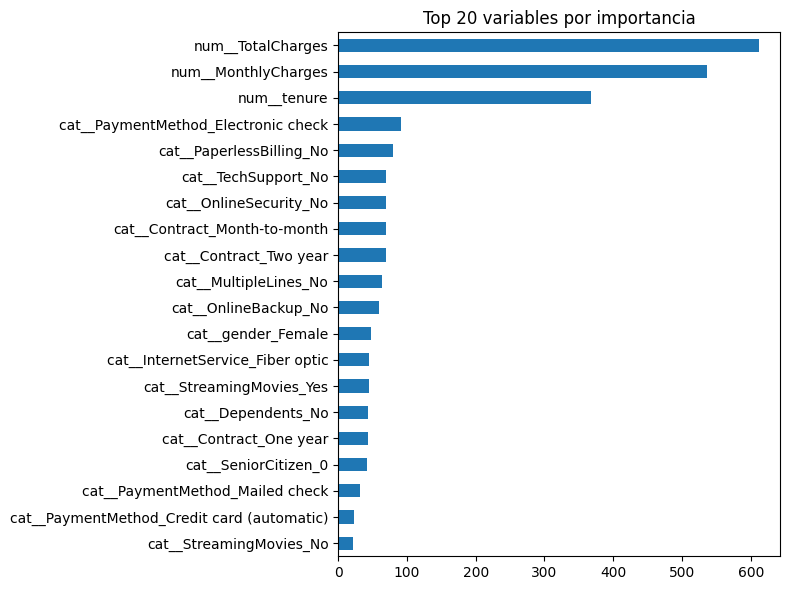

,importance
num__TotalCharges,612
num__MonthlyCharges,537
num__tenure,367
cat__PaymentMethod_Electronic check,91
cat__PaperlessBilling_No,80
cat__TechSupport_No,70
cat__OnlineSecurity_No,70
cat__Contract_Two year,69
cat__Contract_Month-to-month,69
cat__MultipleLines_No,63


In [7]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = (
    pd.Series(model.feature_importances_, index=feature_names, name="importance")
    .sort_values(ascending=False)
    .head(20)
)
feature_importance.sort_values().plot.barh(figsize=(8, 6))
plt.title("Top 20 variables por importancia")
plt.tight_layout()
plt.show()
feature_importance.to_frame()

## 7. Guardado del modelo

In [8]:
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, f"{MODEL_DIR}/churn_lightgbm_model.joblib")
joblib.dump(preprocessor, f"{MODEL_DIR}/churn_lightgbm_preprocessor.joblib")
joblib.dump(
    {"decision_threshold": decision_threshold, "feature_names": feature_names.tolist()},
    f"{MODEL_DIR}/churn_lightgbm_metadata.joblib",
)
print("Artefactos guardados en", MODEL_DIR)

Artefactos guardados en ../models
